In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import load_model

In [18]:
df = pd.read_csv('../data/TSLA.csv')

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df[['Close']]

In [19]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - 60:]   # IMPORTANT (keep this)

In [20]:
def create_sequences(data, seq_length=60):
    X, y = [], []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

X_test, y_test = create_sequences(test_data)

In [21]:
rnn_model = load_model('../models/simplernn_best.keras', compile=False)
lstm_model = load_model('../models/lstm_tuned_best.keras', compile=False)

In [22]:
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [23]:
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)

y_test_actual = scaler.inverse_transform(y_test)

In [24]:
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_pred))
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

print("RNN RMSE:", rnn_rmse)
print("LSTM RMSE:", lstm_rmse)

RNN RMSE: 17.228734416054994
LSTM RMSE: 18.01139058863963


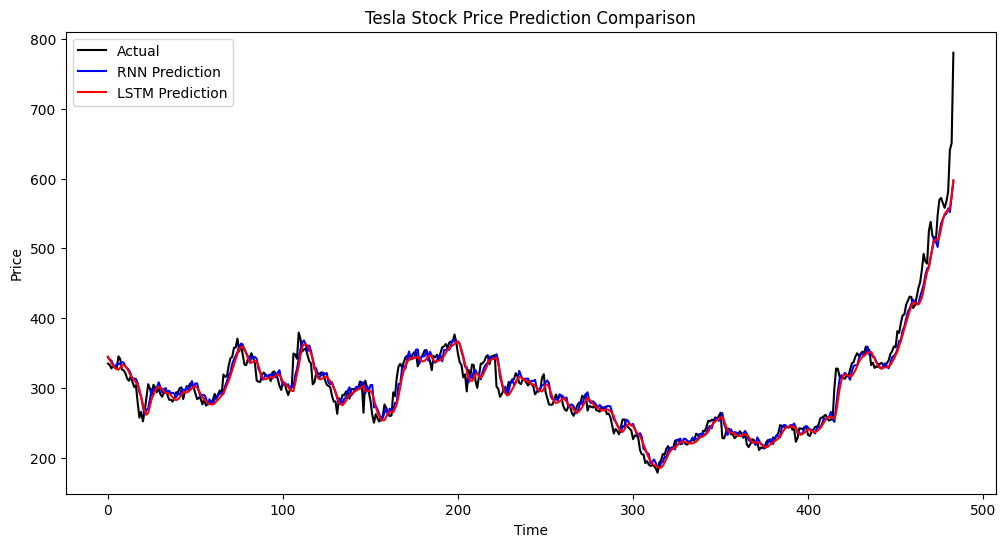

In [25]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual', color='black')
plt.plot(rnn_pred, label='RNN Prediction', color='blue')
plt.plot(lstm_pred, label='LSTM Prediction', color='red')

plt.legend()
plt.title("Tesla Stock Price Prediction Comparison")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()